# 04. 추가 실험
공식 성능 표와 별개로, 오류 분석에서 세운 가설을 확인한다.
1. 순위 예측 성능 : 절대 수명은 틀려도 셀의 열화 순서는 맞는가?
2. 배치 보정 : Batch 2 셀 몇 개의 실제 수명을 알면 오차가 얼마나 줄어드는가?

실험 2는 Batch 2의 정답 일부를 사용하므로 Test 성능으로 보고하지 않는다.

[정제] 배치별 제외 사유 (빈칸 = 사용)
excluded  kept  no_label  not_reach_EOL
batch                                  
b1          36         0             10
b2          39         8              0
b3          44         2              0 

[분할] Train 29 / Valid 7 (Batch 1) · Test 39 (Batch 2)

[성능] MAPE(%) · Gap(%p, (+) = 뒤쪽이 더 나쁨) · Target = 원논문 9.1%
                          Linear (variance)  ElasticNet (main)  ElasticNet (full)  RandomForest (main)  LightGBM (main)
Train (Batch 1 CV)                     9.16               5.77               6.78                 9.53             9.60
Valid (Batch 1 Hold-out)               8.09              19.03              18.31                12.82             9.39
Test (Batch 2)                        29.88              30.32              34.55                33.91            33.52
Gap (Train-Valid)                     -1.07              13.26              11.53                 3.29            -0.20
Gap (Valid-Test)                      21.79              11

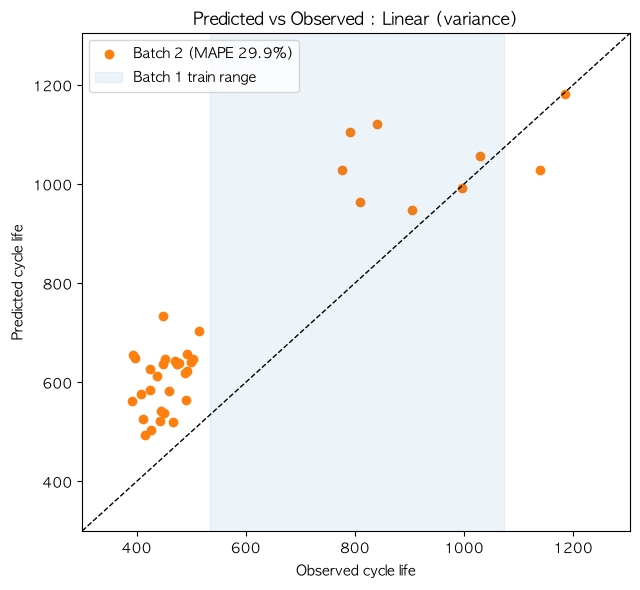

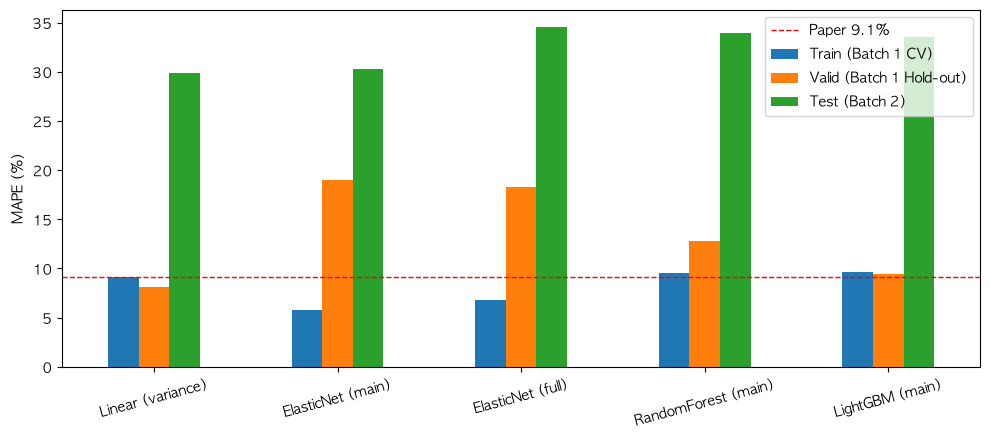

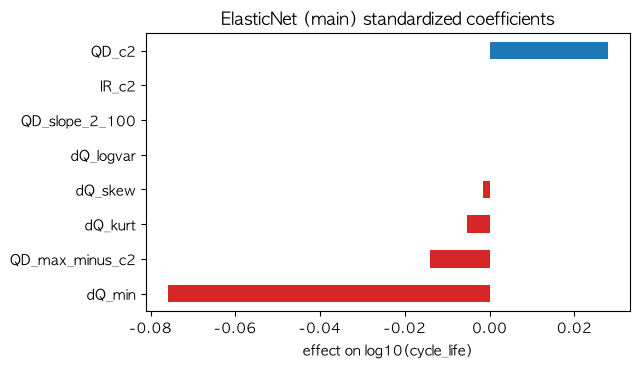

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))
from train import run
out = run(show=False)


===== 추가 실험 (최종 모델 : Linear (variance), Batch 2 39셀) =====

[실험 1] 순위 예측 성능
             대상  셀 수  Spearman 순위상관 하위 25% 선별 적중  단수명(<550) 판별 AUC  MAPE(%)
     Batch 2 전체   39          0.708         5/10               1.0    29.88
newstructure 제외   30          0.379          3/8               NaN    34.09
  newstructure만    9          0.226          0/2               NaN    15.86

[실험 2] 배치 보정 (무작위 k셀 선택을 1,000회 반복, 나머지 셀에서 평가)
 보정에 쓴 셀 수 k  보정 후 MAPE 평균(%)    5~95% 범위  평균만 사용 MAPE(%)
           1            15.32 10.0 ~ 31.3           36.22
           2            13.14 10.0 ~ 22.1           29.74
           3            12.36  9.6 ~ 19.5           28.54
           5            11.59  9.5 ~ 15.8           27.06
          10            10.99  9.2 ~ 13.5           25.40
{'보정 없음': 29.88, '전체 셀로 보정(참고용 상한)': 10.21}


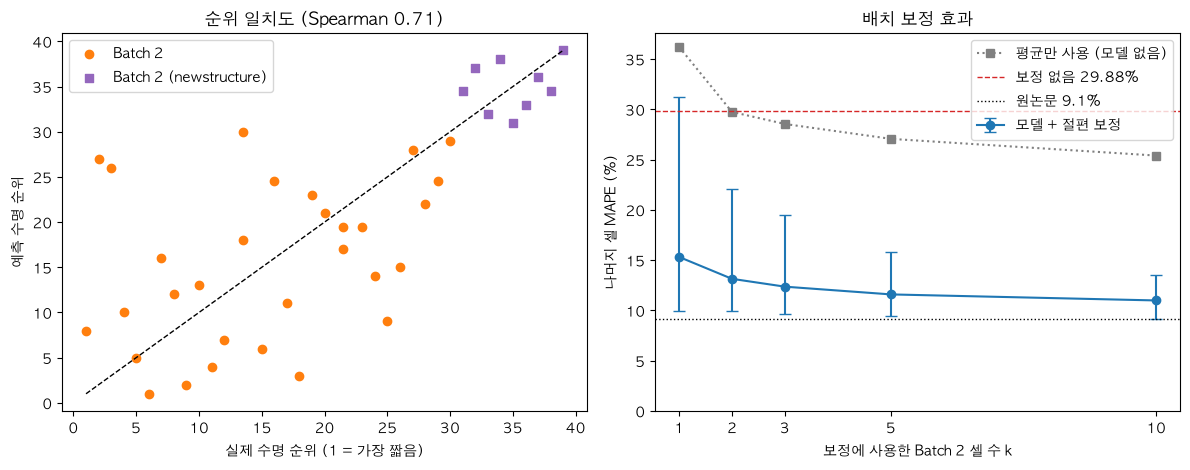


결과 저장 → /Users/parksihyun/Desktop/ess-battery-project/results/extra_experiments.md, extra_experiments.png


In [2]:
from extra import run_extra
ex = run_extra(out)

In [3]:
ex['ranking']

,대상,셀 수,Spearman 순위상관,하위 25% 선별 적중,단수명(<550) 판별 AUC,MAPE(%)
0,Batch 2 전체,39,0.708,5/10,1.0,29.88
1,newstructure 제외,30,0.379,3/8,NaN,34.09
2,newstructure만,9,0.226,0/2,NaN,15.86


In [4]:
ex['calibration']

,보정에 쓴 셀 수 k,보정 후 MAPE 평균(%),5~95% 범위,평균만 사용 MAPE(%)
0,1,15.32,10.0 ~ 31.3,36.22
1,2,13.14,10.0 ~ 22.1,29.74
2,3,12.36,9.6 ~ 19.5,28.54
3,5,11.59,9.5 ~ 15.8,27.06
4,10,10.99,9.2 ~ 13.5,25.40
